In [ ]:
!pip install langchain langgraph langchain_openai langchain_groq --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.9/124.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.1/420.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 11.1 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata
#os.environ["OPENAI_API_KEY"] = userdata.get('OPEN_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [ ]:
# Import ChatModels
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

# Import Langgraph
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [ ]:
# Initialize a LLM
llm=ChatGroq(model="qwen-2.5-32b")
#llm=ChatOpenAI(model="o1-mini")

In [ ]:
# Graph state
class State(TypedDict):
    blog_topic: str
    blog_report_outline: str
    rechecked_outline: str
    rechecked_blog: str
    readability_report: str
    decision: str
    blog_report_generated: str
    improved_blog: str
    final_blog: str



In [ ]:
# Created Nodes

def generate_blog_outline(state: State):
  """
  First LLM call to generate the initial outline on the given topic to write blog.
  """
  blog = llm.invoke(f"Generate a detailed outline to write a blog on {state['blog_topic']}")
  return {"blog_report_outline": blog.content}


def generate_blog(state: State):
  """
  Second LLM Call to generate a detailed blog using the given outline
  """
  blog_report = llm.invoke(f"Generate a detailed blog on topic given these outlines : {state['blog_report_outline']}")
  return {"blog_report_generated": blog_report.content}


def improve_blog(state: State):
  """
  Third LLM Call to improve the blog
  """
  improved_blog = llm.invoke(f"Improve the given blog by adding technical details and real life use cases : {state['blog_report_generated']}")
  return {"improved_blog": improved_blog.content}


def polish_blog(state: State):
  """
  Fourth LLM Call to polish the blog
  """
  final_blog = llm.invoke(f"Polish the given blog so that even a non-technical person can understand the topic, Use Markdown formatting: {state['improved_blog']}")
  return {"final_blog": final_blog.content}


def recheck_outline(state: State):
    """
    Recheck the outline for completeness and relevance.
    """
    rechecked_outline = llm.invoke(f"Recheck and refine the given outline for completeness and relevance: {state['blog_report_outline']}")
    return {"rechecked_outline": rechecked_outline.content}

def recheck_blog(state: State):
    """
    Recheck the generated blog for coherence and accuracy.
    """
    rechecked_blog = llm.invoke(f"Recheck the given blog for coherence and accuracy: {state['blog_report_generated']}")
    return {"rechecked_blog": rechecked_blog.content}

def check_readability(state: State):
    """
    Check if the blog is readable by non-technical persons and return a decision.
    """
    readability_report = llm.invoke(f"Assess if the given blog is understandable by non-technical persons: {state['final_blog']}")
    decision = "pass" if "readable" in readability_report.content else "fail"
    return {"readability_report": readability_report.content, "decision": decision}


# Define a routing function for conditional edges
def readability_routing_function(state: State):
    return "polish_blog" if state['decision'] == 'fail' else END


In [ ]:
# Build the workflow
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("generate_blog_outline", generate_blog_outline)
workflow.add_node("recheck_outline", recheck_outline)
workflow.add_node("generate_blog", generate_blog)
workflow.add_node("recheck_blog", recheck_blog)
workflow.add_node("improve_blog", improve_blog)
workflow.add_node("polish_blog", polish_blog)
#workflow.add_node("check_readability", check_readability)

# Add Edges to connect the nodes
workflow.add_edge(START, "generate_blog_outline")
workflow.add_edge("generate_blog_outline", "recheck_outline")
workflow.add_edge("recheck_outline", "generate_blog")
workflow.add_edge("generate_blog", "recheck_blog")
workflow.add_edge("recheck_blog", "improve_blog")
workflow.add_edge("improve_blog", "polish_blog")
workflow.add_edge("polish_blog", END)

# Add conditional edge for readability check
#workflow.add_conditional_edges("check_readability", readability_routing_function)

# Compile
chain = workflow.compile()

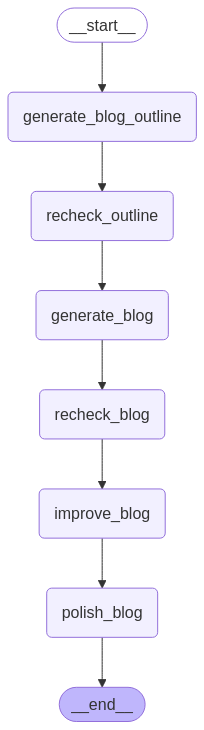

In [ ]:
# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [ ]:
# Invoke
state = chain.invoke({"blog_topic": "Agentic AI for every day use"})

In [ ]:
from IPython.display import Markdown
Markdown(state['final_blog'])

### Agentic AI for Everyday Use

#### Introduction
Artificial Intelligence (AI) is changing how we live and work, and new types of AI are being developed to better fit our lives. One of these is Agentic AI. Agentic AI acts like a smart, autonomous helper. It can make decisions on its own, much like a person would, to help you with tasks and improve how you live and work.

#### What is Agentic AI?
Agentic AI is a type of AI that can make decisions on its own, based on its goals. Unlike programs that follow set rules or guess outcomes based on data, Agentic AI learns from its surroundings and adjusts how it works. It does this by trying things, learning what works best, and then making smarter decisions in the future. Think of it like a smart assistant that learns as it goes.

#### Benefits of Agentic AI in Everyday Life
Agentic AI can make our lives better in many ways:

- **Personalization**: Agentic AI can customize experiences for you, whether it's picking out movies you might like or suggesting diets that work best for your health. It learns what you like and don’t like, and adjusts to fit your preferences.
- **Convenience**: Imagine a home that adjusts itself based on your habits—turning on lights when you enter a room or setting the temperature to your liking. Agentic AI can do this and more, making daily routines smoother and more efficient.
- **Smart Decision Making**: Agentic AI can help you make better decisions. For example, it can analyze financial data to suggest the best investment options, or it can help you choose the best career path based on your skills and interests.
- **Accessibility**: Agentic AI can help people with disabilities live more independently. It can assist in daily tasks, like managing medications or adjusting home settings, making life easier and safer.

#### How Agentic AI Works
Agentic AI works by using advanced learning and decision-making techniques:

- **Learning Algorithms**: Agentic AI uses smart learning methods to understand its environment and improve over time. It learns from experience, much like you would learn a new skill.
- **Decision-Making**: It makes decisions based on what it learns, choosing the best action to take. This could be adjusting home settings or suggesting health plans.
- **Interaction**: Agentic AI interacts with its environment by observing and reacting to changes. It uses sensors and feedback to learn and adapt, making it more effective with each interaction.

#### Real-World Applications of Agentic AI
Agentic AI is already making a difference in various areas:

- **Healthcare**: In hospitals and at home, Agentic AI can monitor patients' health and alert doctors to potential issues. It can also offer personalized treatment plans based on individual patient data.
- **Retail**: In shopping, Agentic AI can analyze what you like and dislike, suggesting products that match your interests. It can also create personalized shopping experiences in stores.
- **Entertainment**: Streaming services can use Agentic AI to tailor movie and music recommendations based not only on what you’ve watched before but also on how you felt about it.

#### Challenges and Considerations
While Agentic AI offers many benefits, there are challenges to address:

- **Privacy**: Protecting your personal information is crucial. Technologies need to be secure to prevent misuse of data.
- **Ethics**: We need to ensure that Agentic AI is fair and unbiased. It should not discriminate against certain groups of people.
- **Impact on Society**: As we rely more on AI, we must plan for changes it might bring, like changes in the job market or how we use technology.

#### Future of Agentic AI
The future of Agentic AI looks bright. As technology improves, we can expect more advanced and personalized AI solutions that integrate seamlessly into our lives. This will likely include more interaction with other technologies, like smart homes and wearable devices, making our lives more efficient and enjoyable.

#### Conclusion
Agentic AI is a powerful tool that can help us in many aspects of life. It learns and adapts, making decisions to help us live better and more efficiently. As we move forward, it’s important to balance the benefits with ethical and privacy concerns to ensure AI serves everyone fairly.

#### Appendices
- **Glossary of Terms**: Explains technical terms used in the article.
- **Further Readings and Resources**: Offers books, articles, and online resources for deeper exploration into Agentic AI.
- **FAQ Section**: Answers common questions about Agentic AI and its applications, helping you understand it better.